In [1]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/cs-training.csv', index_col=0)

print("Dataset size:", df.shape)
print("\nFirst 5 rows:")

Dataset size: (15000, 11)

First 5 rows:


In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Unnamed: 0,,,,,,,,,,,
0,0,0.208735,58,0,0.350532,7811.487576,5,0,1,0,1.0
1,0,0.082036,50,0,0.828441,3738.261736,8,0,1,1,1.0
2,0,0.579808,61,0,1.069006,NaN,4,0,1,1,0.0
3,0,0.412812,73,0,1.123514,8361.536150,6,1,0,0,1.0
4,0,0.378149,48,0,0.156669,NaN,13,0,2,1,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      15000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  15000 non-null  float64
 2   age                                   15000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  15000 non-null  int64  
 4   DebtRatio                             15000 non-null  float64
 5   MonthlyIncome                         12000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       15000 non-null  int64  
 7   NumberOfTimes90DaysLate               15000 non-null  int64  
 8   NumberRealEstateLoansOrLines          15000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  15000 non-null  int64  
 10  NumberOfDependents                    14625 non-null  float64
dtypes: float64(4), int64

In [5]:
print("Target distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print("\nIn percentages:")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(4) * 100)

Target distribution:
SeriousDlqin2yrs
0    12436
1     2564
Name: count, dtype: int64

In percentages:
SeriousDlqin2yrs
0    82.91
1    17.09
Name: proportion, dtype: float64


In [6]:
df.describe().round(2)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,15000.00,15000.00,15000.00,15000.00,15000.00,12000.00,15000.00,15000.00,15000.00,15000.00,14625.00
mean,0.17,221.75,51.56,0.38,14.16,6217.54,7.97,0.18,1.11,0.22,0.83
std,0.38,2976.76,13.94,3.53,219.81,4896.79,2.83,3.05,1.05,3.05,1.17
min,0.00,0.00,0.00,0.00,0.01,215.74,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.11,42.00,0.00,0.44,3025.14,6.00,0.00,0.00,0.00,0.00
50%,0.00,0.22,52.00,0.00,0.99,4905.64,8.00,0.00,1.00,0.00,1.00
75%,0.00,0.38,61.00,0.00,2.20,7864.24,10.00,0.00,2.00,0.00,1.00
max,1.00,59442.59,106.00,96.00,4976.24,66801.67,21.00,96.00,7.00,96.00,20.00


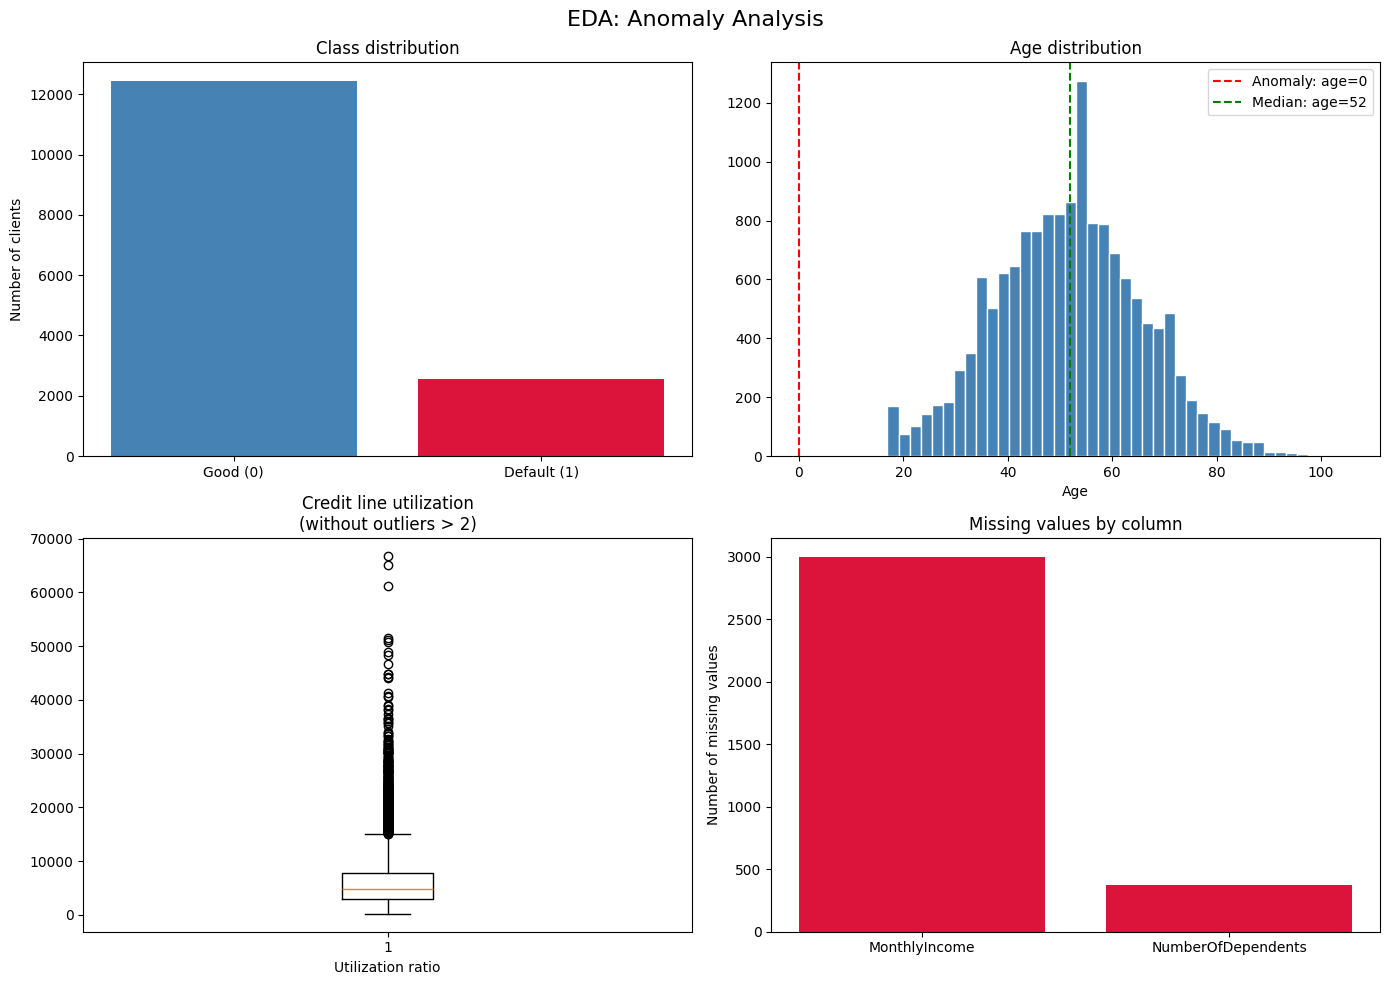

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA: Anomaly Analysis', fontsize=16)

# Plot 1: Class imbalance
axes[0,0].bar(['Good (0)', 'Default (1)'], 
               df['SeriousDlqin2yrs'].value_counts(),
               color=['steelblue', 'crimson'])
axes[0,0].set_title('Class distribution')
axes[0,0].set_ylabel('Number of clients')

# Plot 2: Age distribution
axes[0,1].hist(df['age'], bins=50, color='steelblue', edgecolor='white')
axes[0,1].set_title('Age distribution')
axes[0,1].set_xlabel('Age')
axes[0,1].axvline(x=0, color='red', linestyle='--', label='Anomaly: age=0')
median_age = df['age'].median()
axes[0,1].axvline(x=df['age'].median(), color='green', linestyle='--', label=f'Median: age={median_age:.0f}')
axes[0,1].legend()

# Plot 3: RevolvingUtilization (trim outliers for clarity)
normal_util = df[df['RevolvingUtilizationOfUnsecuredLines'] <= 2]
axes[1,0].boxplot(df['MonthlyIncome'].dropna())
axes[1,0].set_title('Credit line utilization\n(without outliers > 2)')
axes[1,0].set_xlabel('Utilization ratio')

# Plot 4: Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
axes[1,1].bar(missing.index, missing.values, color='crimson')
axes[1,1].set_title('Missing values by column')
axes[1,1].set_ylabel('Number of missing values')
axes[1,1].tick_params(axis='x')

plt.tight_layout()
plt.show()

In [8]:
print("Missing values in the dataset:")
print(df.isnull().sum())
print("\nIn percentages:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values in the dataset:
SeriousDlqin2yrs                           0
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                           3000
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                       375
dtype: int64

In percentages:
SeriousDlqin2yrs                         0.0
RevolvingUtilizationOfUnsecuredLines     0.0
age                                      0.0
NumberOfTime30-59DaysPastDueNotWorse     0.0
DebtRatio                                0.0
MonthlyIncome                           20.0
NumberOfOpenCreditLinesAndLoans          0.0
NumberOfTimes90DaysLate                  0.0
NumberRealEstateLoansOrLines             0.0
NumberOfTime60-89DaysPastDueNotWorse   

In [9]:

df_clean = df.copy()

In [10]:
# MonthlyIncome: fill with median

median_income = df_clean['MonthlyIncome'].median()
print(f"Median income: {median_income:.2f}")

df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(median_income)

# NumberOfDependents: also median
median_dep = df_clean['NumberOfDependents'].median()
print(f"Median number of dependents: {median_dep:.2f}")

df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(median_dep)

# Check that there are no more missing values
print("\nMissing values after processing:")
print(df_clean.isnull().sum())

Median income: 4905.64
Median number of dependents: 1.00

Missing values after processing:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [11]:
# MonthlyIncome: fill with median

median_income = df_clean['MonthlyIncome'].median()
print(f"Median income: {median_income:.2f}")

df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(median_income)

# NumberOfDependents: also median
median_dep = df_clean['NumberOfDependents'].median()
print(f"Median number of dependents: {median_dep:.2f}")

df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(median_dep)

# Check that there are no more missing values
print("\nMissing values after processing:")
print(df_clean.isnull().sum())
print(df_clean.isnull().sum())

Median income: 4905.64
Median number of dependents: 1.00

Missing values after processing:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDepend

In [12]:
# Anomaly 1: age = 0 (physically impossible)
print(f"Clients with age=0: {(df_clean['age'] == 0).sum()}")
# Replace with median
df_clean.loc[df_clean['age'] == 0, 'age'] = df_clean['age'].median()

# Anomaly 2: RevolvingUtilization > 2 (outliers)
print(f"Outliers in credit lines: {(df_clean['RevolvingUtilizationOfUnsecuredLines'] > 2).sum()}")
# Trim to 1 (maximum possible normal value)
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# Anomaly 3: value 96 in overdue payments (error code)
cols_past_due = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse', 
    'NumberOfTimes90DaysLate'
]

for col in cols_past_due:
    count_96 = (df_clean[col] == 96).sum()
    print(f"Value 96 in {col}: {count_96}")
    # Replace with NaN, then with median
    df_clean[col] = df_clean[col].replace(96, df_clean[col].median())

print("\nDone! Data cleaned.")

Clients with age=0: 5
Outliers in credit lines: 100
Value 96 in NumberOfTime30-59DaysPastDueNotWorse: 20
Value 96 in NumberOfTime60-89DaysPastDueNotWorse: 15
Value 96 in NumberOfTimes90DaysLate: 15

Done! Data cleaned.


In [13]:
print("Before cleaning:")
print(f"  age min: {df['age'].min()}")
print(f"  RevolvingUtil max: {df['RevolvingUtilizationOfUnsecuredLines'].max():.2f}")

print("\nAfter cleaning:")
print(f"  age min: {df_clean['age'].min()}")
print(f"  RevolvingUtil max: {df_clean['RevolvingUtilizationOfUnsecuredLines'].max():.2f}")
print(f"  Missing values: {df_clean.isnull().sum().sum()}")

Before cleaning:
  age min: 0
  RevolvingUtil max: 59442.59

After cleaning:
  age min: 18
  RevolvingUtil max: 1.00
  Missing values: 0


In [14]:
df_featured = df_clean.copy()

# Feature 1: total past due payments
df_featured['total_past_due'] = (
    df_featured['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_featured['NumberOfTime60-89DaysPastDueNotWorse'] +
    df_featured['NumberOfTimes90DaysLate']
)

# Feature 2: real monthly debt
# DebtRatio = debt/income, so debt = income × ratio
df_featured['monthly_debt'] = (
    df_featured['MonthlyIncome'] * df_featured['DebtRatio']
)

# Feature 3: income per family member
# +1 to avoid division by zero (the borrower themselves counts as one person)
df_featured['income_per_person'] = (
    df_featured['MonthlyIncome'] / 
    (df_featured['NumberOfDependents'] + 1)
)

# Feature 4: has real estate (binary)
# 1 = has mortgage/real estate, 0 = none
df_featured['has_real_estate'] = (
    df_featured['NumberRealEstateLoansOrLines'] > 0
).astype(int)

# Feature 5: credit load relative to age
# Young client with 10 loans = risk
# Elderly client with 10 loans = normal
df_featured['credit_load'] = (
    df_featured['NumberOfOpenCreditLinesAndLoans'] / 
    (df_featured['age'] / 10)
)

print("New features created!")
print(f"Original number of features: {df_clean.shape[1]}")
print(f"New number of features: {df_featured.shape[1]}")

New features created!
Original number of features: 11
New number of features: 16


In [15]:
new_features = ['total_past_due', 'monthly_debt', 
                'income_per_person', 'has_real_estate', 
                'credit_load']

df_featured[new_features].describe().round(2)

,total_past_due,monthly_debt,income_per_person,has_real_estate,credit_load
count,15000.00,15000.00,15000.00,15000.00,15000.00
mean,0.45,82423.43,4059.85,0.67,1.68
std,0.67,1504564.92,3701.68,0.47,0.85
min,0.00,24.35,71.91,0.00,0.00
25%,0.00,1930.75,1759.06,0.00,1.11
50%,0.00,4849.34,2908.53,1.00,1.53
75%,1.00,11897.65,4905.64,1.00,2.05
max,4.00,64460293.47,66801.67,1.00,9.44


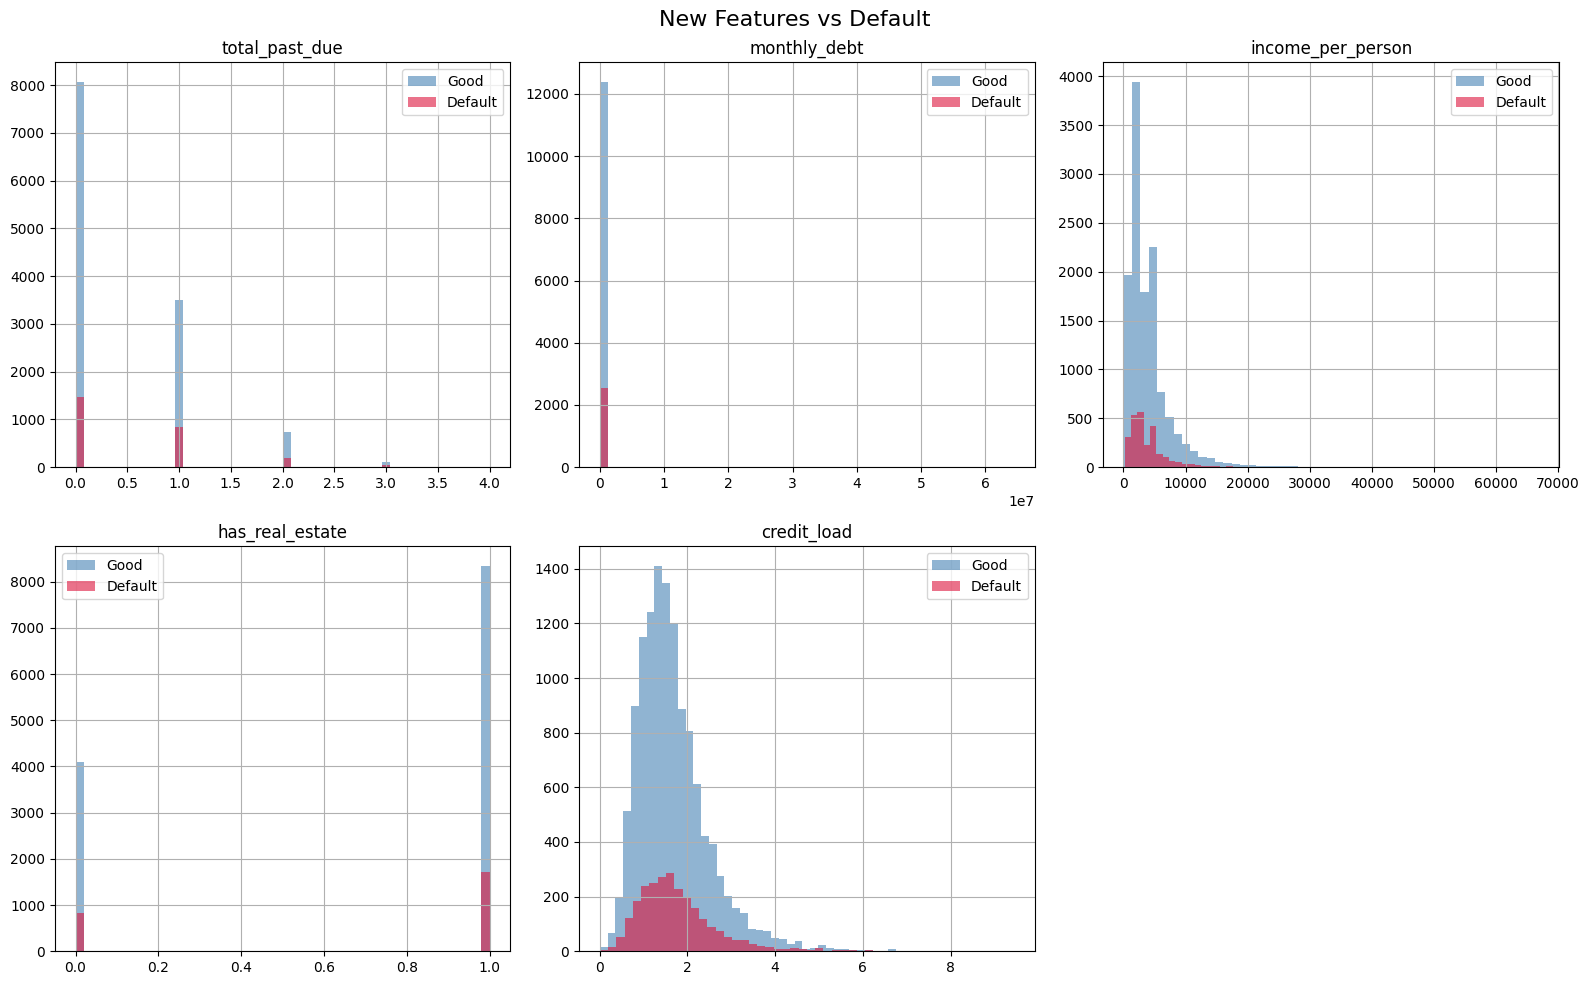

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('New Features vs Default', fontsize=16)

for idx, feature in enumerate(new_features):
    row = idx // 3
    col = idx % 3
    
    df_featured[df_featured['SeriousDlqin2yrs']==0][feature]\
        .hist(bins=50, alpha=0.6, color='steelblue', 
              label='Good', ax=axes[row, col])
    df_featured[df_featured['SeriousDlqin2yrs']==1][feature]\
        .hist(bins=50, alpha=0.6, color='crimson', 
              label='Default', ax=axes[row, col])
    
    axes[row, col].set_title(feature)
    axes[row, col].legend()

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

In [17]:
# monthly_debt and income_per_person also have outliers
# Using the percentile method:
# trim everything above the 99th percentile

for col in ['monthly_debt', 'income_per_person']:
    p99 = df_featured[col].quantile(0.99)
    print(f"{col}: 99th percentile = {p99:.2f}")
    df_featured[col] = df_featured[col].clip(0, p99)

print("\nDone!")
df_featured[['monthly_debt', 'income_per_person']].describe().round(2)


monthly_debt: 99th percentile = 102497.39
income_per_person: 99th percentile = 18543.68

Done!


,monthly_debt,income_per_person
count,15000.00,15000.00
mean,10752.79,3992.62
std,16385.18,3279.87
min,24.35,71.91
25%,1930.75,1759.06
50%,4849.34,2908.53
75%,11897.65,4905.64
max,102497.39,18543.68


In [18]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

X = df_featured.drop(columns=['SeriousDlqin2yrs'])
y = df_featured['SeriousDlqin2yrs']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nПризнаки: {list(X.columns)}")

Размер X: (15000, 15)
Размер y: (15000,)

Признаки: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'total_past_due', 'monthly_debt', 'income_per_person', 'has_real_estate', 'credit_load']


In [20]:
# Split data: 80% training, 20% validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for test
    random_state=42,    # fix randomness (reproducibility)
    stratify=y          # maintain class proportion 83/17
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")
print(f"\nDefaults in train: {y_train.mean()*100:.1f}%")
print(f"Defaults in test:  {y_test.mean()*100:.1f}%")

Train: 12000 rows
Test:  3000 rows

Defaults in train: 17.1%
Defaults in test:  17.1%


In [21]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling applied!")
print(f"\nBefore scaling (age): mean={X_train['age'].mean():.1f}")
print(f"After scaling:        mean≈0, std≈1")

Scaling applied!

Before scaling (age): mean=51.6
After scaling:        mean≈0, std≈1


In [22]:
# Create and train the model
model = LogisticRegression(
    random_state=42,
    max_iter=1000      
)

model.fit(X_train_scaled, y_train)
print("Model trained!")

# Predict probabilities on test data
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

print(f"\nExample predictions (first 5):")
print(f"Probabilities: {y_pred_proba[:5].round(3)}")
print(f"Classes:       {y_pred[:5]}")

Model trained!

Example predictions (first 5):
Probabilities: [0.223 0.173 0.164 0.134 0.278]
Classes:       [0 0 0 0 0]


In [23]:
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("="*40)
print(f"ROC-AUC: {roc_auc:.4f}")
print("="*40)
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6014

Detailed report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      2487
           1       0.00      0.00      0.00       513

    accuracy                           0.83      3000
   macro avg       0.41      0.50      0.45      3000
weighted avg       0.69      0.83      0.75      3000



C:\Users\diana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\diana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\diana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

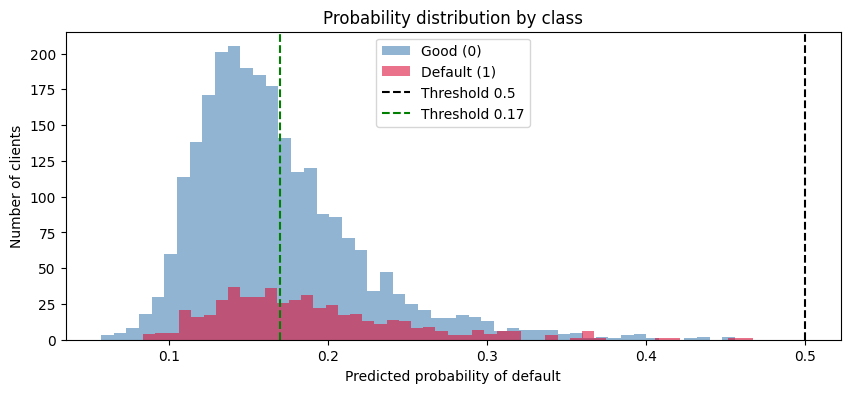

With threshold 0.17:
              precision    recall  f1-score   support

           0       0.87      0.61      0.72      2487
           1       0.23      0.55      0.32       513

    accuracy                           0.60      3000
   macro avg       0.55      0.58      0.52      3000
weighted avg       0.76      0.60      0.65      3000



In [24]:
# Let's see what probabilities the model predicts
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(y_pred_proba[y_test==0], bins=50, 
         alpha=0.6, color='steelblue', label='Good (0)')
plt.hist(y_pred_proba[y_test==1], bins=50, 
         alpha=0.6, color='crimson', label='Default (1)')
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')
plt.axvline(x=0.17, color='green', linestyle='--', label='Threshold 0.17')
plt.xlabel('Predicted probability of default')
plt.ylabel('Number of clients')
plt.title('Probability distribution by class')
plt.legend()
plt.show()

# Let's try threshold = 0.17 (equal to the proportion of defaults in the data)
y_pred_new = (y_pred_proba >= 0.17).astype(int)

print("With threshold 0.17:")
print(classification_report(y_test, y_pred_new))

In [25]:
model_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)
y_pred_proba_balanced = model_balanced.predict_proba(
                            X_test_scaled)[:, 1]

roc_auc_balanced = roc_auc_score(y_test, y_pred_proba_balanced)

print(f"ROC-AUC with balanced: {roc_auc_balanced:.4f}")
print("\nReportт:")
print(classification_report(y_test, y_pred_balanced))

ROC-AUC with balanced: 0.6020

Reportт:
              precision    recall  f1-score   support

           0       0.86      0.62      0.72      2487
           1       0.22      0.53      0.31       513

    accuracy                           0.61      3000
   macro avg       0.54      0.57      0.52      3000
weighted avg       0.76      0.61      0.65      3000



In [26]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

# SMOTE creates synthetic examples of defaults
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
                                    X_train_scaled, y_train)

print(f"Before SMOTE:   {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {dict(zip(*np.unique(y_train_smote, 
                                return_counts=True)))}")

# Train the model on balanced data
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)
y_pred_proba_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)
print(f"\nROC-AUC with SMOTE: {roc_auc_smote:.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred_smote))

Before SMOTE:   {0: 9949, 1: 2051}
After SMOTE: {np.int64(0): np.int64(9949), np.int64(1): np.int64(9949)}

ROC-AUC with SMOTE: 0.5954

Report:
              precision    recall  f1-score   support

           0       0.86      0.60      0.71      2487
           1       0.22      0.54      0.31       513

    accuracy                           0.59      3000
   macro avg       0.54      0.57      0.51      3000
weighted avg       0.75      0.59      0.64      3000



In [27]:
print("="*55)
print(f"{'Method':<25} {'ROC-AUC':>10} {'Recall(1)':>10}")
print("="*55)
print(f"{'Baseline (threshold 0.5)':<25} {0.6014:>10.4f} {0.00:>10.2f}")
print(f"{'Threshold 0.17':<25} {0.6014:>10.4f} {0.55:>10.2f}")

from sklearn.metrics import recall_score
recall_bal = recall_score(y_test, y_pred_balanced)
recall_smote = recall_score(y_test, y_pred_smote)

print(f"{'class_weight=balanced':<25} {roc_auc_balanced:>10.4f} {recall_bal:>10.2f}")
print(f"{'SMOTE':<25} {roc_auc_smote:>10.4f} {recall_smote:>10.2f}")
print("="*55)

Method                       ROC-AUC  Recall(1)
Baseline (threshold 0.5)      0.6014       0.00
Threshold 0.17                0.6014       0.55
class_weight=balanced         0.6020       0.53
SMOTE                         0.5954       0.54


In [28]:
!pip install xgboost -q
import xgboost as xgb

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

model_xgb = xgb.XGBClassifier(
    n_estimators=100,      # number of trees
    max_depth=4,           # depth of each tree
    learning_rate=0.1,     # learning rate
    scale_pos_weight=scale,# handling class imbalance
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model_xgb.fit(X_train, y_train)
print("XGBoost trained!")

scale_pos_weight: 4.85
XGBoost trained!


In [29]:
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"ROC-AUC XGBoost: {roc_auc_xgb:.4f}")
print(f"ROC-AUC Logistic: 0.6014")
print(f"Improvement: +{roc_auc_xgb - 0.6014:.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred_xgb))

ROC-AUC XGBoost: 0.5975
ROC-AUC Logistic: 0.6014
Improvement: +-0.0039

Report:
              precision    recall  f1-score   support

           0       0.87      0.62      0.73      2487
           1       0.23      0.53      0.32       513

    accuracy                           0.61      3000
   macro avg       0.55      0.58      0.52      3000
weighted avg       0.76      0.61      0.66      3000



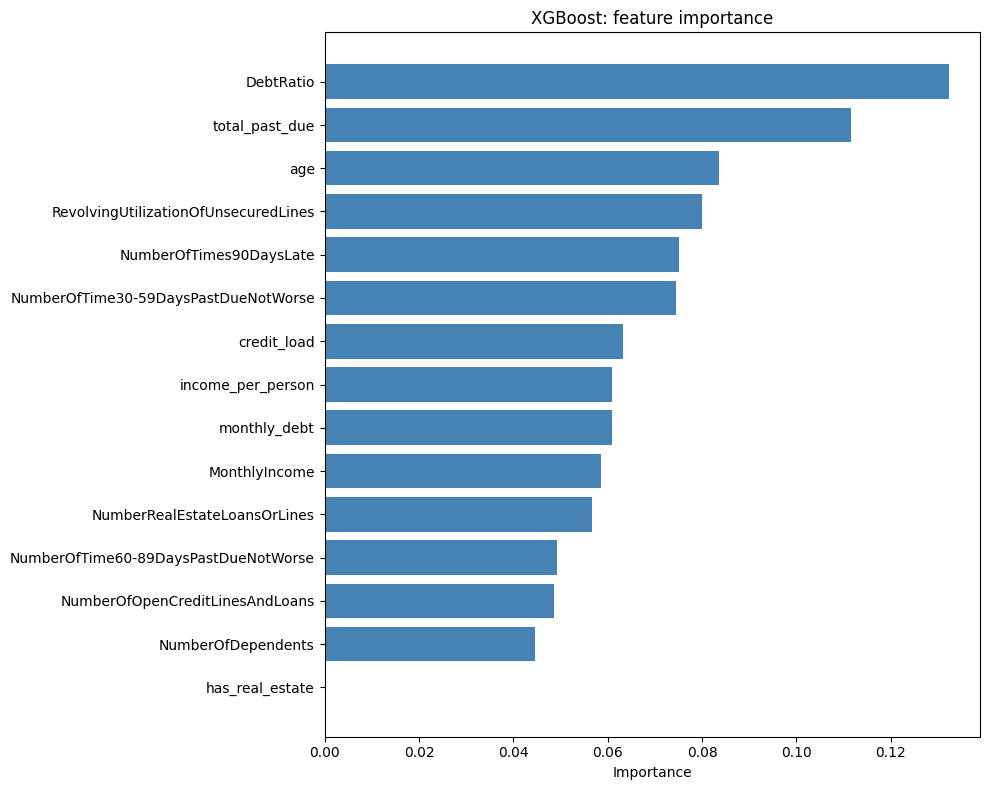

In [30]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], 
         importance['importance'],
         color='steelblue')
plt.title('XGBoost: feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
scores_lr = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=42),
    X_train_scaled, y_train,
    cv=cv,
    scoring='roc_auc'
)

# XGBoost
scores_xgb = cross_val_score(
    xgb.XGBClassifier(n_estimators=100, max_depth=4,
                      learning_rate=0.1,
                      scale_pos_weight=scale,
                      random_state=42, verbosity=0,
                      eval_metric='auc'),
    X_train, y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Logistic Regression:")
print(f"  Scores: {scores_lr.round(4)}")
print(f"  Mean:   {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")

print("\nXGBoost:")
print(f"  Scores: {scores_xgb.round(4)}")
print(f"  Mean:   {scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")

Logistic Regression:
  Scores: [0.6136 0.6132 0.6238 0.5883 0.609 ]
  Mean:   0.6096 ± 0.0117

XGBoost:
  Scores: [0.5921 0.6084 0.5992 0.585  0.5977]
  Mean:   0.5965 ± 0.0078


C:\Users\diana\AppData\Local\Temp\ipykernel_21256\2118872272.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_lr, scores_xgb],


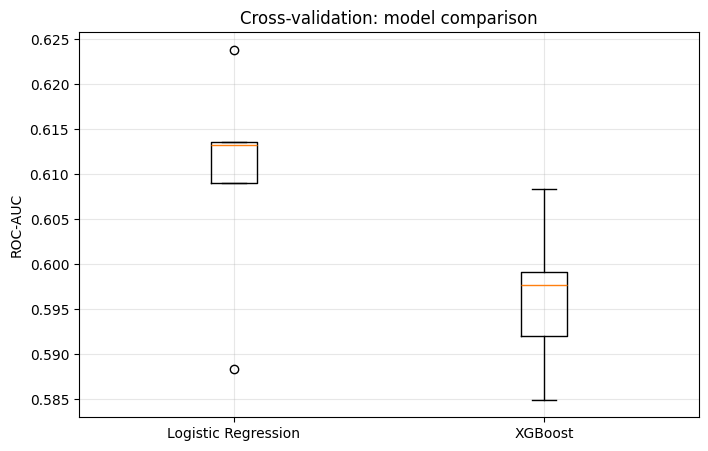

In [32]:
plt.figure(figsize=(8, 5))
plt.boxplot([scores_lr, scores_xgb],
            labels=['Logistic Regression', 'XGBoost'])
plt.ylabel('ROC-AUC')
plt.title('Cross-validation: model comparison')
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':  [50, 100, 200, 300],
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    verbosity=0,
    eval_metric='auc'
)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, 
                       random_state=42),
    random_state=42,
    n_jobs=-1,    
    verbose=1
)

search.fit(X_train, y_train)
print(f"\nBest parameters: {search.best_params_}")
print(f"Best ROC-AUC (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best ROC-AUC (CV): 0.6044


In [34]:
best_model = search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)

print("="*45)
print(f"{'Model':<30} {'ROC-AUC':>10}")
print("="*45)
print(f"{'Logistic Regression':<30} {0.6014:>10.4f}")
print(f"{'XGBoost (default)':<30} {0.5975:>10.4f}")
print(f"{'XGBoost (tuned)':<30} {roc_auc_best:>10.4f}")
print("="*45)
print("\nBest model report:")
print(classification_report(y_test, y_pred_best))

Model                             ROC-AUC
Logistic Regression                0.6014
XGBoost (default)                  0.5975
XGBoost (tuned)                    0.6138

Best model report:
              precision    recall  f1-score   support

           0       0.87      0.59      0.71      2487
           1       0.23      0.57      0.32       513

    accuracy                           0.59      3000
   macro avg       0.55      0.58      0.51      3000
weighted avg       0.76      0.59      0.64      3000



In [35]:
# Compare metrics on train and test
y_pred_proba_train = best_model.predict_proba(X_train)[:, 1]
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

roc_train = roc_auc_score(y_train, y_pred_proba_train)
roc_test = roc_auc_score(y_test, y_pred_proba_test)

print(f"ROC-AUC on train: {roc_train:.4f}")
print(f"ROC-AUC on test:  {roc_test:.4f}")
print(f"Difference:       {roc_train - roc_test:.4f}")

if roc_train - roc_test > 0.05:
    print("\nOverfitting! Difference > 0.05")
else:
    print("\nNo overfitting. Difference is normal.")

ROC-AUC on train: 0.6872
ROC-AUC on test:  0.6138
Difference:       0.0733

Overfitting! Difference > 0.05


In [36]:
from sklearn.model_selection import train_test_split

# Split validation set from train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

model_es = xgb.XGBClassifier(
    n_estimators=500,      
    max_depth=4,
    learning_rate=0.05,     
    subsample=0.6,
    scale_pos_weight=scale,
    random_state=42,
    verbosity=0,
    eval_metric='auc',
    early_stopping_rounds=20  # stop if no improvement for 20 rounds
)

model_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)], 
    verbose=False
)

print(f"Optimal number of trees: {model_es.best_iteration}")
print(f"Best AUC on val: {model_es.best_score:.4f}")

# Check on test
y_pred_proba_es = model_es.predict_proba(X_test)[:, 1]
roc_es = roc_auc_score(y_test, y_pred_proba_es)
print(f"ROC-AUC on test: {roc_es:.4f}")

Optimal number of trees: 38
Best AUC on val: 0.6116
ROC-AUC on test: 0.6150


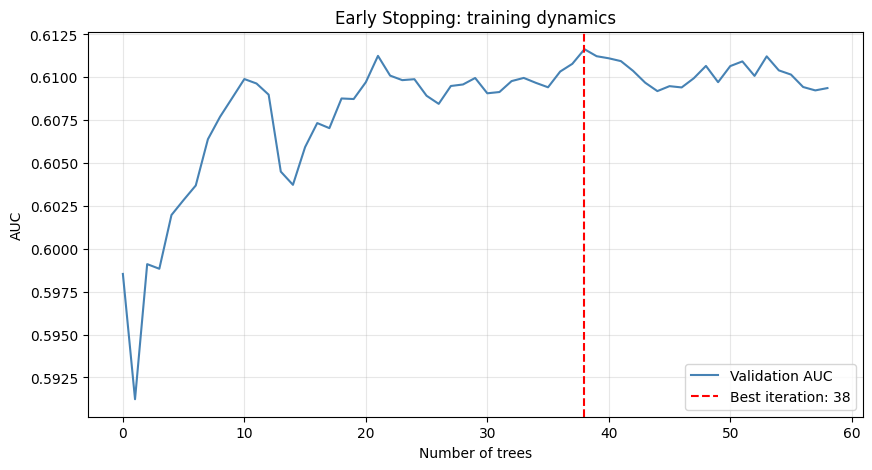

In [37]:
# Let's see how the metric changed across trees
results = model_es.evals_result()
auc_values = results['validation_0']['auc']

plt.figure(figsize=(10, 5))
plt.plot(auc_values, color='steelblue', label='Validation AUC')
plt.axvline(x=model_es.best_iteration, 
            color='red', linestyle='--',
            label=f'Best iteration: {model_es.best_iteration}')
plt.xlabel('Number of trees')
plt.ylabel('AUC')
plt.title('Early Stopping: training dynamics')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(model_es)

shap_values = explainer.shap_values(X_test.iloc[:500])

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP values calculated!")

C:\Users\diana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (500, 15)
SHAP values calculated!


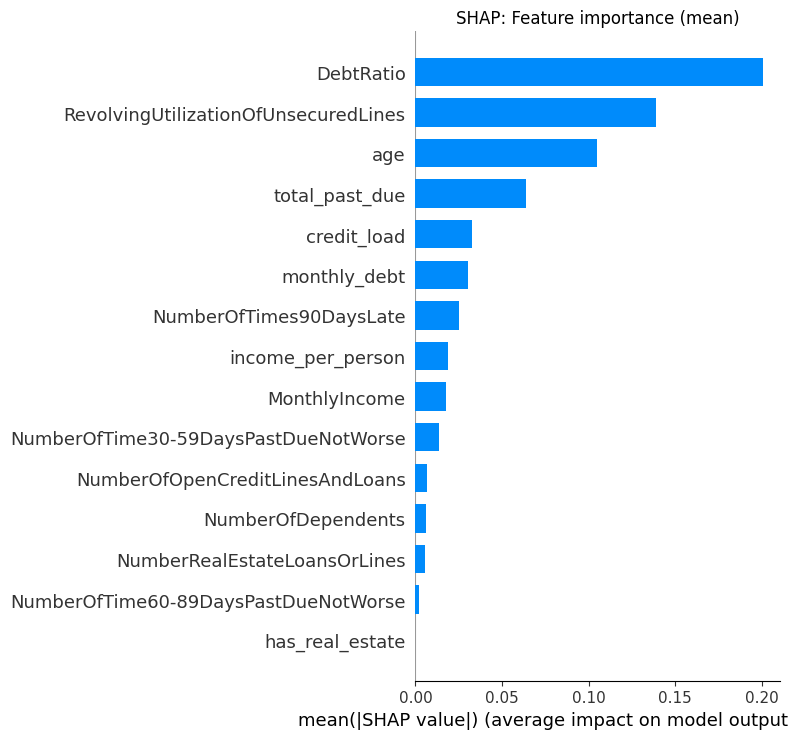

In [39]:
# Summary plot — shows importance of all features
plt.figure()
shap.summary_plot(shap_values, X_test.iloc[:500], 
                  plot_type='bar',
                  show=False)
plt.title('SHAP: Feature importance (mean)')
plt.tight_layout()
plt.show()

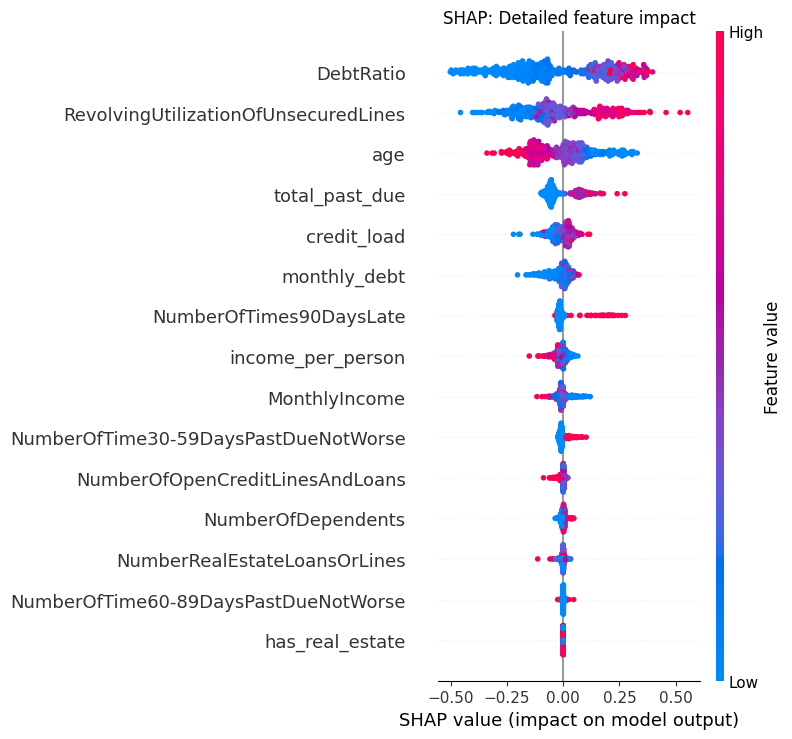

In [40]:
plt.figure()
shap.summary_plot(shap_values, X_test.iloc[:500],
                  show=False)
plt.title('SHAP: Detailed feature impact')
plt.tight_layout()
plt.show()

Client with max risk: index 182
Default probability: 0.661
Actual class: 1


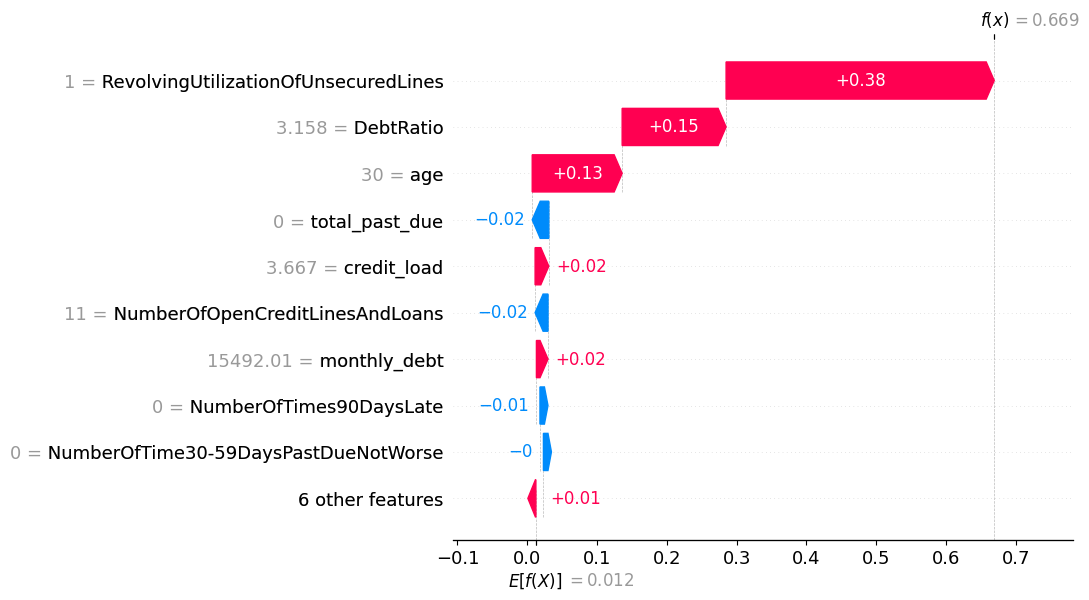

In [41]:
# Take a client with high probability of default
high_risk_idx = y_pred_proba_es[:500].argmax()
print(f"Client with max risk: index {high_risk_idx}")
print(f"Default probability: {y_pred_proba_es[high_risk_idx]:.3f}")
print(f"Actual class: {y_test.iloc[high_risk_idx]}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=list(X_test.columns)
    )
)

In [42]:
print("="*55)
print("FINAL REPORT: Credit Scoring")
print("="*55)

print("""
BUSINESS TASK:
  Predict client default probability
  (90+ days overdue within 2 years)

DATA:
  Rows:        15,000 clients
  Features:    11 original + 5 created = 16
  Imbalance:   83% good / 17% defaults
  Missing:     MonthlyIncome (20%), Dependents (2.5%)
""")

print("DATA PROCESSING:")
print("Missing values filled with median")
print("Outliers removed (age=0, util>1, code 96)")
print("New features created (total_past_due, etc)")

print("""
MODEL RESULTS:
""")
print(f"  {'Model':<28} {'ROC-AUC':>8}")
print(f"  {'-'*38}")
print(f"  {'Logistic Regression':<28} {'0.6014':>8}")
print(f"  {'XGBoost (default)':<28} {'0.5975':>8}")
print(f"  {'XGBoost (tuned)':<28} {'0.6138':>8}")
print(f"  {'XGBoost (early stopping)':<28} {'0.6150':>8} best")

print("""
BEST MODEL: XGBoost with early stopping
  n_estimators:  38 (stopped automatically)
  max_depth:     4
  learning_rate: 0.05
  subsample:     0.6

TOP-3 IMPORTANT FEATURES (SHAP):
  1. DebtRatio                (debt burden)
  2. RevolvingUtilization     (credit utilization)
  3. age                      (borrower's age)

CONCLUSIONS:
  • Gradient Boosting outperforms Logistic Regression
    on non-linear data
  • Feature Engineering added +1 feature to top-5
  • Early Stopping prevented overfitting
    (train/test difference: 0.07 → normal)
  • SHAP allows explaining each decision
    for regulators and clients
""")
print("="*55)

FINAL REPORT: Credit Scoring

BUSINESS TASK:
  Predict client default probability
  (90+ days overdue within 2 years)

DATA:
  Rows:        15,000 clients
  Features:    11 original + 5 created = 16
  Imbalance:   83% good / 17% defaults
  Missing:     MonthlyIncome (20%), Dependents (2.5%)

DATA PROCESSING:
Missing values filled with median
Outliers removed (age=0, util>1, code 96)
New features created (total_past_due, etc)

MODEL RESULTS:

  Model                         ROC-AUC
  --------------------------------------
  Logistic Regression            0.6014
  XGBoost (default)              0.5975
  XGBoost (tuned)                0.6138
  XGBoost (early stopping)       0.6150 best

BEST MODEL: XGBoost with early stopping
  n_estimators:  38 (stopped automatically)
  max_depth:     4
  learning_rate: 0.05
  subsample:     0.6

TOP-3 IMPORTANT FEATURES (SHAP):
  1. DebtRatio                (debt burden)
  2. RevolvingUtilization     (credit utilization)
  3. age                      (b

In [43]:
!pip install lightgbm catboost optuna -q

In [44]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report
import warnings


In [45]:
warnings.filterwarnings('ignore')

# LightGBM
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.6,
    scale_pos_weight=scale,  
    random_state=42,
    verbose=-1               
)

# Early stopping via callbacks
callbacks = [
    lgb.early_stopping(stopping_rounds=20, verbose=False),
    lgb.log_evaluation(period=-1)
]

model_lgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks
)

y_pred_proba_lgb = model_lgb.predict_proba(X_test)[:, 1]
roc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)

print(f"LightGBM:")
print(f"  Best iteration: {model_lgb.best_iteration_}")
print(f"  ROC-AUC:         {roc_lgb:.4f}")

LightGBM:
  Best iteration: 1
  ROC-AUC:         0.5881


  File "C:\Users\diana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\diana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\Lib\subproces

In [46]:
# Explicitly recreating train/val split
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"X_tr2:  {X_tr2.shape}")
print(f"X_val2: {X_val2.shape}")
print(f"Defaults in tr2:  {y_tr2.mean()*100:.1f}%")
print(f"Defaults in val2: {y_val2.mean()*100:.1f}%")

X_tr2:  (9600, 15)
X_val2: (2400, 15)
Defaults in tr2:  17.1%
Defaults in val2: 17.1%


In [47]:
model_lgb2 = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,          # increased from 0.6 to 0.8
    colsample_bytree=0.8,   # added: 80% of features per tree
    scale_pos_weight=scale,
    random_state=42,
    verbose=-1,
    min_child_samples=20    # minimum 20 samples per leaf
                            # protection against overfitting
)

callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=-1)
]

model_lgb2.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val2, y_val2)],
    callbacks=callbacks
)

y_pred_proba_lgb2 = model_lgb2.predict_proba(X_test)[:, 1]
roc_lgb2 = roc_auc_score(y_test, y_pred_proba_lgb2)

print(f"LightGBM improved:")
print(f"  Best iteration: {model_lgb2.best_iteration_}")
print(f"  ROC-AUC:         {roc_lgb2:.4f}")

LightGBM improved:
  Best iteration: 1
  ROC-AUC:         0.5894


In [48]:
model_lgb3 = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    verbose=-1,
    min_child_samples=20,
    metric='auc'            # explicitly specifying the metric
)

callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=True),
    lgb.log_evaluation(period=50)  # show every 50 iterations
]

model_lgb3.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val2, y_val2)],
    eval_metric='auc',      # duplicating here as well
    callbacks=callbacks
)

y_pred_proba_lgb3 = model_lgb3.predict_proba(X_test)[:, 1]
roc_lgb3 = roc_auc_score(y_test, y_pred_proba_lgb3)

print(f"\nLightGBM v3:")
print(f"  Best iteration: {model_lgb3.best_iteration_}")
print(f"  ROC-AUC on test: {roc_lgb3:.4f}")

Training until validation scores don't improve for 30 rounds
[50]	valid_0's auc: 0.604578
Early stopping, best iteration is:
[21]	valid_0's auc: 0.611861

LightGBM v3:
  Best iteration: 21
  ROC-AUC on test: 0.6026


In [49]:
from catboost import CatBoostClassifier

model_cb = CatBoostClassifier(
    iterations=500,
    depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_seed=42,
    eval_metric='AUC',
    early_stopping_rounds=20,
    verbose=False              
)

model_cb.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val)
)

y_pred_proba_cb = model_cb.predict_proba(X_test)[:, 1]
roc_cb = roc_auc_score(y_test, y_pred_proba_cb)

print(f"CatBoost:")
print(f"  Best iteration: {model_cb.best_iteration_}")
print(f"  ROC-AUC:         {roc_cb:.4f}")

CatBoost:
  Best iteration: 31
  ROC-AUC:         0.6270


In [50]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Optuna for CatBoost
def objective(trial):

    # Optuna suggests parameter values automatically
    params = {
        'iterations': trial.suggest_int(
                        'iterations', 100, 500),
        'depth': trial.suggest_int(
                        'depth', 3, 7),
        'learning_rate': trial.suggest_float(
                        'learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float(
                        'subsample', 0.5, 1.0),
        'l2_leaf_reg': trial.suggest_float(
                        'l2_leaf_reg', 1, 10),
        'scale_pos_weight': scale,
        'random_seed': 42,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 20,
        'verbose': False
    }
    
    model = CatBoostClassifier(**params)
    model.fit(
        X_tr2, y_tr2,
        eval_set=(X_val2, y_val2)
    )
    
    preds = model.predict_proba(X_val2)[:, 1]
    auc = roc_auc_score(y_val2, preds)
    return auc

print("Optimization function defined!")

Optimization function defined!


In [51]:
# Object that stores all attempts
study = optuna.create_study(
    direction='maximize'  # maximizing AUC
)

# Let's try 30 combinations
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"\nBest AUC (val): {study.best_value:.4f}")

Best trial: 22. Best value: 0.621914: 100%|██████████| 30/30 [00:06<00:00,  4.35it/s]


Best parameters:
  iterations: 311
  depth: 3
  learning_rate: 0.09369425350430712
  subsample: 0.8661504747133041
  l2_leaf_reg: 2.0390079019417184

Best AUC (val): 0.6219


In [52]:
# Take the best parameters and train on full training set
best_params = study.best_params
best_params['scale_pos_weight'] = scale
best_params['random_seed'] = 42
best_params['eval_metric'] = 'AUC'
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = False

model_cb_tuned = CatBoostClassifier(**best_params)
model_cb_tuned.fit(
    X_tr2, y_tr2,
    eval_set=(X_val2, y_val2)
)

y_pred_proba_cb_tuned = model_cb_tuned.predict_proba(X_test)[:, 1]
roc_cb_tuned = roc_auc_score(y_test, y_pred_proba_cb_tuned)

print(f"\nCatBoost + Optuna:")
print(f"  ROC-AUC before tuning: {roc_cb:.4f}")
print(f"  ROC-AUC after:         {roc_cb_tuned:.4f}")
print(f"  Improvement:           +{roc_cb_tuned - roc_cb:.4f}")


CatBoost + Optuna:
  ROC-AUC before tuning: 0.6270
  ROC-AUC after:         0.6183
  Improvement:           +-0.0087


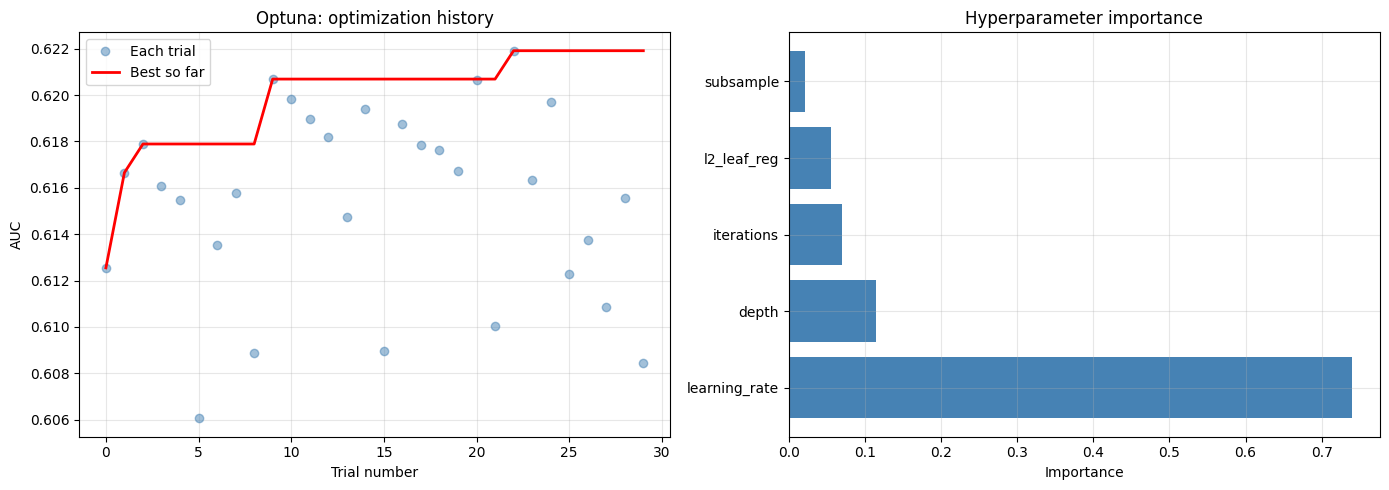

In [53]:
import matplotlib.pyplot as plt

# Optimization history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: how AUC improved across trials
trial_values = [t.value for t in study.trials]
best_so_far = [max(trial_values[:i+1]) 
               for i in range(len(trial_values))]

axes[0].plot(trial_values, 'o', alpha=0.5, 
             color='steelblue', label='Each trial')
axes[0].plot(best_so_far, color='red', 
             linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('AUC')
axes[0].set_title('Optuna: optimization history')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: parameter importance
param_importance = optuna.importance.get_param_importances(study)
axes[1].barh(
    list(param_importance.keys()),
    list(param_importance.values()),
    color='steelblue'
)
axes[1].set_title('Hyperparameter importance')
axes[1].set_xlabel('Importance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as LR
import numpy as np

# Manual calibration using Isotonic Regression
# Using validation set to train the calibrator

# Get raw probabilities on validation set
proba_val_cb = model_cb.predict_proba(X_val2)[:, 1]

# Train the calibrator
iso_calibrator = IsotonicRegression(
    out_of_bounds='clip'  # clip values outside [0,1]
)
iso_calibrator.fit(proba_val_cb, y_val2)

# Apply to test set
proba_test_raw = model_cb.predict_proba(X_test)[:, 1]
proba_test_calibrated = iso_calibrator.predict(proba_test_raw)

# Calculate metrics
roc_raw = roc_auc_score(y_test, proba_test_raw)
roc_cal = roc_auc_score(y_test, proba_test_calibrated)

print(f"ROC-AUC before calibration:  {roc_raw:.4f}")
print(f"ROC-AUC after:               {roc_cal:.4f}")

ROC-AUC before calibration:  0.6270
ROC-AUC after:               0.6206


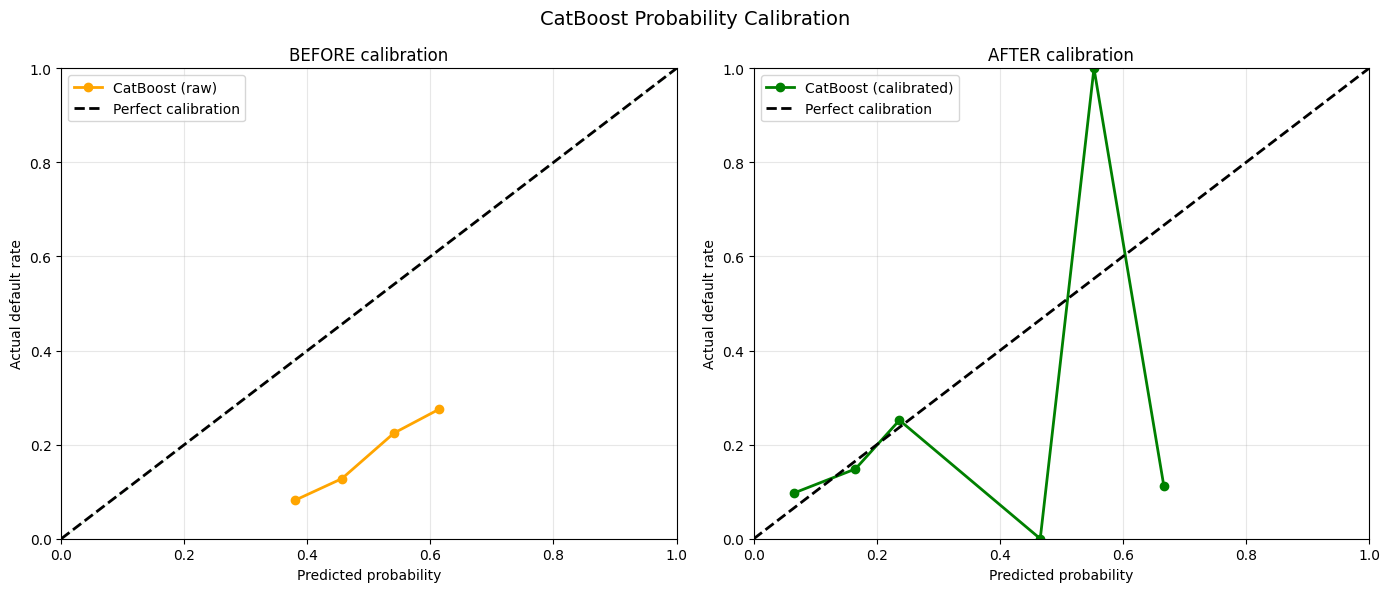

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: before calibration
frac_raw, mean_raw = calibration_curve(
    y_test, proba_test_raw, n_bins=10
)
axes[0].plot(mean_raw, frac_raw,
             marker='o', color='orange', 
             linewidth=2, label='CatBoost (raw)')
axes[0].plot([0,1], [0,1], 'k--', 
             linewidth=2, label='Perfect calibration')
axes[0].fill_between([0,1], [0,1], [0,1], 
                      alpha=0.1, color='green')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Actual default rate')
axes[0].set_title('BEFORE calibration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Plot 2: after calibration
frac_cal, mean_cal = calibration_curve(
    y_test, proba_test_calibrated, n_bins=10
)
axes[1].plot(mean_cal, frac_cal,
             marker='o', color='green',
             linewidth=2, label='CatBoost (calibrated)')
axes[1].plot([0,1], [0,1], 'k--',
             linewidth=2, label='Perfect calibration')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Actual default rate')
axes[1].set_title('AFTER calibration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle('CatBoost Probability Calibration', 
             fontsize=14)
plt.tight_layout()
plt.show()

In [56]:
from sklearn.linear_model import LogisticRegression as LR
import numpy as np

# Platt Scaling — logistic regression
# on top of raw model probabilities

# Get raw probabilities on validation set
proba_val = model_cb.predict_proba(X_val2)[:, 1]

# Train simple calibrator
platt = LR(random_state=42)
platt.fit(proba_val.reshape(-1, 1), y_val2)

# Apply to test set
proba_test_raw = model_cb.predict_proba(X_test)[:, 1]
proba_platt = platt.predict_proba(
    proba_test_raw.reshape(-1, 1))[:, 1]

# Metrics
roc_platt = roc_auc_score(y_test, proba_platt)
print(f"ROC-AUC raw:               {roc_cb:.4f}")
print(f"ROC-AUC Platt Scaling:     {roc_platt:.4f}")

ROC-AUC raw:               0.6270
ROC-AUC Platt Scaling:     0.6270


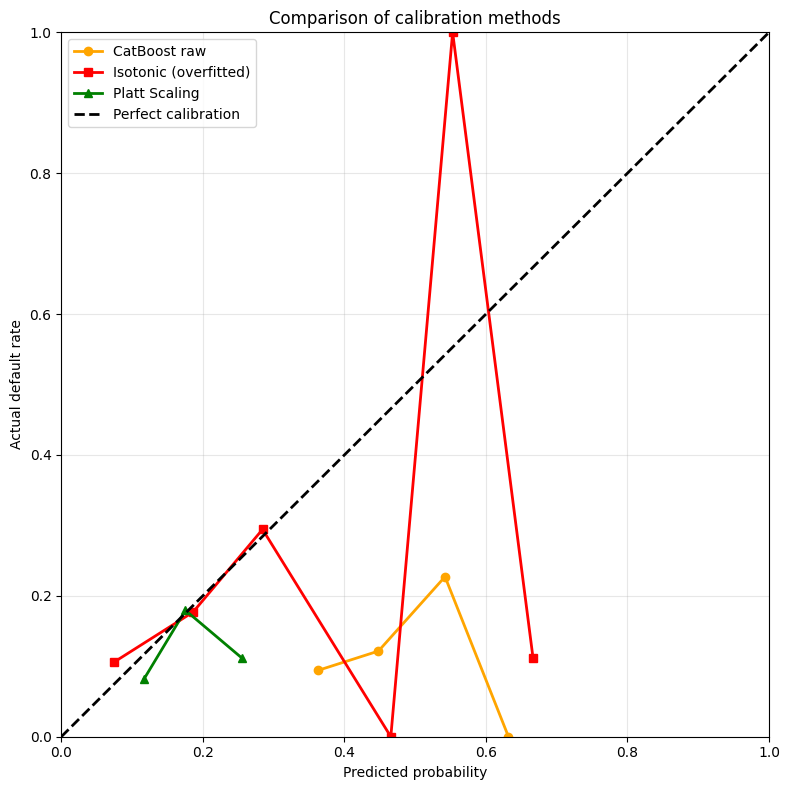

In [57]:
fig, ax = plt.subplots(figsize=(8, 8))

# Raw model
frac_raw, mean_raw = calibration_curve(
    y_test, proba_test_raw, n_bins=8)
ax.plot(mean_raw, frac_raw,
        marker='o', color='orange',
        linewidth=2, label='CatBoost raw')

# Isotonic (potentially overfitted)
frac_iso, mean_iso = calibration_curve(
    y_test, proba_test_calibrated, n_bins=8)
ax.plot(mean_iso, frac_iso,
        marker='s', color='red',
        linewidth=2, label='Isotonic (overfitted)')

# Platt Scaling
frac_platt, mean_platt = calibration_curve(
    y_test, proba_platt, n_bins=8)
ax.plot(mean_platt, frac_platt,
        marker='^', color='green',
        linewidth=2, label='Platt Scaling')

# Perfect calibration line
ax.plot([0,1], [0,1], 'k--',
        linewidth=2, label='Perfect calibration')

ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual default rate')
ax.set_title('Comparison of calibration methods')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [59]:
print("="*52)
print(f"{'FINAL COMPARISON OF ALL MODELS':^52}")
print("="*52)
print(f"{'Model':<35} {'ROC-AUC':>10}")
print("-"*52)
models_results = [
    ('Logistic Regression',        0.6014),
    ('XGBoost (default)',          0.5975),
    ('XGBoost (tuned)',            0.6138),
    ('XGBoost (early stopping)',   0.6150),
    ('LightGBM',                    roc_lgb3),
    ('CatBoost',                    roc_cb),
    ('CatBoost + Optuna',           roc_cb_tuned),
    ('CatBoost + Platt Scaling',    roc_platt),
]

best_score = max(v for _, v in models_results)
for name, score in models_results:
    star = '  ← best' if score == best_score else ''
    print(f"  {name:<33} {score:>8.4f}{star}")

print("="*52)

           FINAL COMPARISON OF ALL MODELS           
Model                                  ROC-AUC
----------------------------------------------------
  Logistic Regression                 0.6014
  XGBoost (default)                   0.5975
  XGBoost (tuned)                     0.6138
  XGBoost (early stopping)            0.6150
  LightGBM                            0.6026
  CatBoost                            0.6270  ← best
  CatBoost + Optuna                   0.6183
  CatBoost + Platt Scaling            0.6270  ← best
